# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results.

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone.


In [1]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingClassifier

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



In [2]:
from sklearn.ensemble import HistGradientBoostingRegressor

In [3]:
random_seed = 42

### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:**

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [4]:
# Add as many cells as you need
df = pd.read_csv("zillow_cleaned.csv")

In [5]:
df.head()

,airconditioningtypeid,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedfinishedsquarefeet,fips,garagecarcnt,garagetotalsqft,heatingorsystemtypeid,latitude,...,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,unitcnt,yearbuilt,numberofstories,censustractandblock,taxvaluedollarcnt
0,1.0,3.5,4.0,6.4072,3100.0,6059.0,2.000000,633.00000,2.0,33634931.0,...,53571.0,1286.0,118849.0,96978.0,0.0,1.0,1998.0,1.0,6.059063e+13,1023282.0
1,1.0,1.0,2.0,6.4072,1465.0,6111.0,1.000000,0.00000,2.0,34449266.0,...,13091.0,2061.0,118849.0,97099.0,5.0,1.0,1967.0,1.0,6.111001e+13,464000.0
2,1.0,2.0,3.0,6.4072,1243.0,6059.0,2.000000,440.00000,2.0,33886168.0,...,21412.0,1286.0,118849.0,97078.0,6.0,1.0,1962.0,1.0,6.059022e+13,564778.0
3,1.0,3.0,4.0,8.0000,2376.0,6037.0,1.775842,330.01199,2.0,34245180.0,...,396551.0,3101.0,118849.0,96330.0,0.0,1.0,1970.0,1.0,6.037300e+13,145143.0
4,1.0,3.0,3.0,8.0000,1312.0,6037.0,1.775842,330.01199,2.0,34185120.0,...,12447.0,3101.0,268548.0,96451.0,0.0,1.0,1964.0,1.0,6.037124e+13,119407.0


In [6]:
y = df["taxvaluedollarcnt"]
y.head()

0    1023282.0
1     464000.0
2     564778.0
3     145143.0
4     119407.0
Name: taxvaluedollarcnt, dtype: float64

In [7]:
X = df.drop(columns="taxvaluedollarcnt")
X.head()

,airconditioningtypeid,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedfinishedsquarefeet,fips,garagecarcnt,garagetotalsqft,heatingorsystemtypeid,latitude,...,propertyzoningdesc,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,unitcnt,yearbuilt,numberofstories,censustractandblock
0,1.0,3.5,4.0,6.4072,3100.0,6059.0,2.000000,633.00000,2.0,33634931.0,...,1833.0,53571.0,1286.0,118849.0,96978.0,0.0,1.0,1998.0,1.0,6.059063e+13
1,1.0,1.0,2.0,6.4072,1465.0,6111.0,1.000000,0.00000,2.0,34449266.0,...,1833.0,13091.0,2061.0,118849.0,97099.0,5.0,1.0,1967.0,1.0,6.111001e+13
2,1.0,2.0,3.0,6.4072,1243.0,6059.0,2.000000,440.00000,2.0,33886168.0,...,1833.0,21412.0,1286.0,118849.0,97078.0,6.0,1.0,1962.0,1.0,6.059022e+13
3,1.0,3.0,4.0,8.0000,2376.0,6037.0,1.775842,330.01199,2.0,34245180.0,...,767.0,396551.0,3101.0,118849.0,96330.0,0.0,1.0,1970.0,1.0,6.037300e+13
4,1.0,3.0,3.0,8.0000,1312.0,6037.0,1.775842,330.01199,2.0,34185120.0,...,571.0,12447.0,3101.0,268548.0,96451.0,0.0,1.0,1964.0,1.0,6.037124e+13


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, shuffle=True)

In [9]:
X_train.head()

,airconditioningtypeid,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedfinishedsquarefeet,fips,garagecarcnt,garagetotalsqft,heatingorsystemtypeid,latitude,...,propertyzoningdesc,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,unitcnt,yearbuilt,numberofstories,censustractandblock
49643,13.0,2.0,3.0,6.4072,1533.0,6059.0,2.000000,498.00000,2.0,33863052.0,...,1833.0,16764.0,1286.0,113455.0,97027.0,7.0,1.0,1975.0,1.0,6.059022e+13
51722,13.0,3.0,4.0,6.4072,2674.0,6059.0,2.000000,471.00000,2.0,33588349.0,...,1833.0,12773.0,1286.0,118849.0,96995.0,9.0,1.0,1980.0,2.0,6.059032e+13
34287,1.0,1.0,2.0,4.0000,873.0,6037.0,1.775842,330.01199,7.0,34304325.0,...,564.0,12447.0,3101.0,34213.0,96368.0,0.0,1.0,1955.0,1.0,6.037106e+13
47744,1.0,2.5,2.0,6.4072,1460.0,6059.0,2.000000,420.00000,6.0,33779089.0,...,1833.0,24832.0,1286.0,118849.0,97052.0,6.0,1.0,1974.0,2.0,6.059110e+13
18035,1.0,1.0,2.0,4.0000,676.0,6037.0,1.775842,330.01199,2.0,34483536.0,...,665.0,25621.0,3101.0,118849.0,97324.0,0.0,1.0,1981.0,1.0,6.037911e+13


In [10]:
y_train.head()

49643    343174.0
51722    853000.0
34287    103274.0
47744    415237.0
18035     37129.0
Name: taxvaluedollarcnt, dtype: float64

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**.


In [12]:
# Set Model for LinearRegression
linear_model = LinearRegression()

# Cross-Validation (5 folds, 5 repeats)
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

# Calculate the scores
linear_scores = cross_val_score(linear_model, X_train_scaled, y_train, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)

# Convert to positive MAE
linear_mae_scores = np.abs(linear_scores)

# Report results
print(f'Mean MAE: {np.mean(linear_mae_scores):.4f}')
print(f'Standard Deviation: {np.std(linear_mae_scores):.4f}')



Mean MAE: 153276.3349
Standard Deviation: 3230.3091


In [13]:
# Set Model for RandomForestRegressor
random_forest_model = RandomForestRegressor()

# Cross-Validation (5 folds, 5 repeats)
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

# Calculate the scores
random_forest_scores = cross_val_score(random_forest_model, X_train_scaled, y_train, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)

# Convert to positive MAE
random_forest_mae_scores = np.abs(random_forest_scores)

# Report results
print(f'Mean MAE: {np.mean(random_forest_mae_scores):.4f}')
print(f'Standard Deviation: {np.std(random_forest_mae_scores):.4f}')

Mean MAE: 135761.3862
Standard Deviation: 1011.9357


In [14]:
# Set Model for HistGradientBoostingClassifier
gradient_boosting_model = HistGradientBoostingRegressor()

# Cross-Validation (5 folds, 5 repeats)
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

# Calculate the scores
gradient_boosting_scores = cross_val_score(gradient_boosting_model, X_train_scaled, y_train, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)

# Convert to positive MAE
gradient_boosting_mae_scores = np.abs(gradient_boosting_scores)

# Report results
print(f'Mean MAE: {np.mean(gradient_boosting_mae_scores):.4f}')
print(f'Standard Deviation: {np.std(gradient_boosting_mae_scores):.4f}')

Mean MAE: 134799.5601
Standard Deviation: 1050.4903


### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

> Out of the LinearRegression, RandomForestRegressor and HistGradientBoostingRegressor models, the HistGradientBoostingRegressor model performed best with the training data. It had both a lower MAE and standard deviation than the other models which indicated that it was the most accurate and the most stable model across the Kfolds. The LinearRegression model contained much higher MAE and standard deviation scores which suggest signs of underfitting.

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1.

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler`
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [15]:
# Add as many cells as you need


def add_engineered_features(X):
    X_eng = X.copy()
    X_eng['log_calculatedfinishedsquarefeet'] = np.log1p(X_eng['calculatedfinishedsquarefeet'])
    X_eng['sqft_per_room'] = X_eng['calculatedfinishedsquarefeet'] / (X_eng['roomcnt'] + 1)
    X_eng['bath_bed_ratio'] = X_eng['bathroomcnt'] / (X_eng['bedroomcnt'] + 1)
    return X_eng

X_train_eng = add_engineered_features(X_train)
X_test_eng  = add_engineered_features(X_test)

# Re-scale including new features
scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled  = scaler_eng.transform(X_test_eng)

print(f"Original feature count: {X_train.shape[1]}")
print(f"Engineered feature count: {X_train_eng.shape[1]}")

Original feature count: 24
Engineered feature count: 27


In [16]:
# Remove rows where the target variable (y_train) is missing
# This ensures X_train and y_train have matching rows for model training

nan_mask = y_train.isnull()
y_train_clean = y_train[~nan_mask]
X_train_eng_scaled_clean = X_train_eng_scaled[~nan_mask]

print(f"NaNs in y_train after fix: {y_train_clean.isnull().sum()}")
print(f"Shape: {X_train_eng_scaled_clean.shape}, {y_train_clean.shape}")

NaNs in y_train after fix: 0
Shape: (57907, 27), (57907,)


In [17]:
# Linear Regression on engineered features
linear_model = LinearRegression()
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
linear_scores_eng = cross_val_score(linear_model, X_train_eng_scaled_clean, y_train_clean,
                                     scoring='neg_mean_absolute_error', cv=cv, n_jobs=2)
linear_mae_eng = np.abs(linear_scores_eng)
print(f'Linear Regression (Engineered)')
print(f'Mean MAE: {np.mean(linear_mae_eng):.4f}')
print(f'Standard Deviation: {np.std(linear_mae_eng):.4f}')

Linear Regression (Engineered)
Mean MAE: 152977.5442
Standard Deviation: 3052.6358


In [18]:
# Random Forest on engineered features
random_forest_model = RandomForestRegressor(n_estimators=50, random_state=random_state, n_jobs=1)
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
random_forest_scores_eng = cross_val_score(random_forest_model, X_train_eng_scaled_clean, y_train_clean,
                                            scoring='neg_mean_absolute_error', cv=cv, n_jobs=1)
random_forest_mae_eng = np.abs(random_forest_scores_eng)
print(f'Random Forest (Engineered)')
print(f'Mean MAE: {np.mean(random_forest_mae_eng):.4f}')
print(f'Standard Deviation: {np.std(random_forest_mae_eng):.4f}')

Random Forest (Engineered)
Mean MAE: 136238.4384
Standard Deviation: 1109.6842


In [19]:
# Hist Gradient Boosting on engineered features
gradient_boosting_model = HistGradientBoostingRegressor(random_state=random_state)
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
gradient_boosting_scores_eng = cross_val_score(gradient_boosting_model, X_train_eng_scaled_clean, y_train_clean,
                                                scoring='neg_mean_absolute_error', cv=cv, n_jobs=1)
gradient_boosting_mae_eng = np.abs(gradient_boosting_scores_eng)
print(f'Hist Gradient Boosting (Engineered)')
print(f'Mean MAE: {np.mean(gradient_boosting_mae_eng):.4f}')
print(f'Standard Deviation: {np.std(gradient_boosting_mae_eng):.4f}')

Hist Gradient Boosting (Engineered)
Mean MAE: 134791.4626
Standard Deviation: 1059.0241


### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




After adding the three engineered features, "log_calculatedfinishedsquarefeet", "sqft_per_room", and "bath_bed_ratio", the results were a bit surprising. The only model that actually improved was Linear Regression, which dropped from 153,276 to 152,977 MAE. That makes sense because log transformations help linear models deal with skewed data better, so "log_calculatedfinishedsquarefeet" likely contributed the most there. Random Forest and Hist Gradient Boosting both got very slightly worse, which honestly is not too concerning. Ensemble methods are already really good at finding patterns and interactions between features on their own, so manually adding things like "sqft_per_room" and "bath_bed_ratio" does not give them much new information they were not already picking up. Overall the new features did not hurt anything significantly, but they also did not dramatically improve performance, which suggests the original 24 features were already pretty informative for the ensemble models.

### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [20]:
# Add as many cells as you need
# Get feature importances from Random Forest
import pandas as pd

rf_selector = RandomForestRegressor(n_estimators=50, random_state=random_state, n_jobs=1)
rf_selector.fit(X_train_eng_scaled_clean, y_train_clean)

# Get feature names
feature_names = X_train_eng.columns.tolist()

# Create importance dataframe
importances = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

print(importances)

                             feature  importance
24  log_calculatedfinishedsquarefeet    0.147663
4       calculatedfinishedsquarefeet    0.139565
9                           latitude    0.130330
21                         yearbuilt    0.103825
10                         longitude    0.087826
11                 lotsizesquarefeet    0.074127
18                       regionidzip    0.060676
23               censustractandblock    0.047687
25                     sqft_per_room    0.039941
3              buildingqualitytypeid    0.027198
26                    bath_bed_ratio    0.020762
17              regionidneighborhood    0.020193
14                propertyzoningdesc    0.020037
15                      regionidcity    0.018044
7                    garagetotalsqft    0.015896
2                         bedroomcnt    0.010462
12         propertycountylandusecode    0.009282
1                        bathroomcnt    0.008074
8              heatingorsystemtypeid    0.004677
13             prope

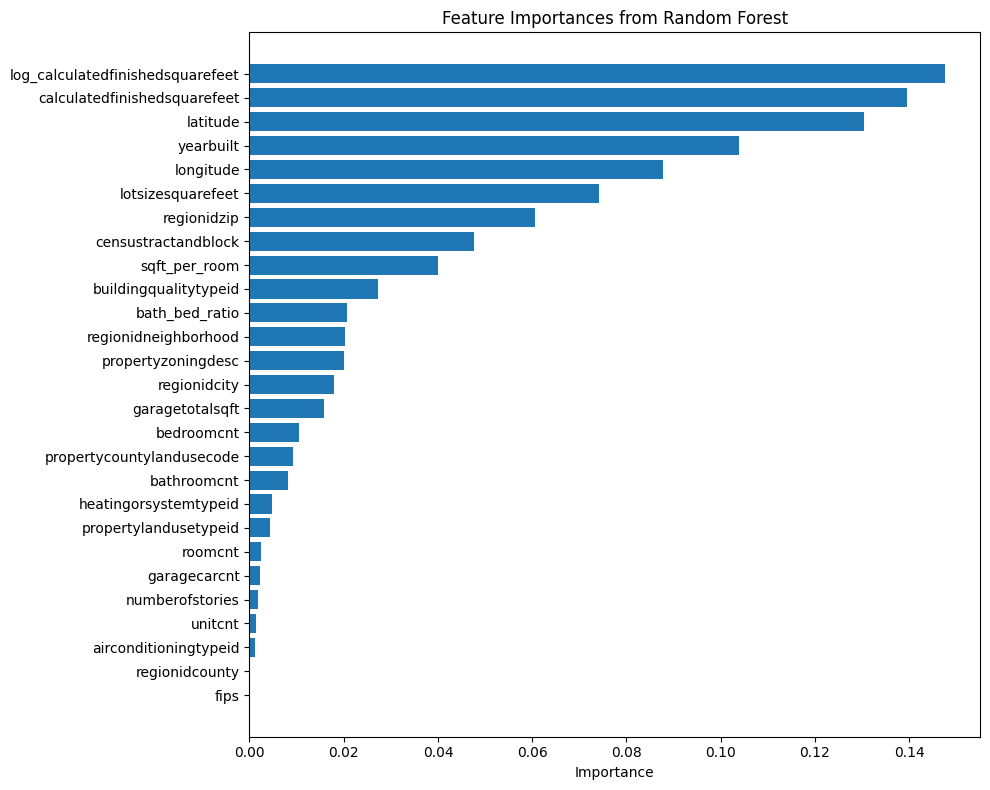


Selected 16 features:
['log_calculatedfinishedsquarefeet', 'calculatedfinishedsquarefeet', 'latitude', 'yearbuilt', 'longitude', 'lotsizesquarefeet', 'regionidzip', 'censustractandblock', 'sqft_per_room', 'buildingqualitytypeid', 'bath_bed_ratio', 'regionidneighborhood', 'propertyzoningdesc', 'regionidcity', 'garagetotalsqft', 'bedroomcnt']


In [21]:
# Plot feature importances
plt.figure(figsize=(10, 8))
plt.barh(importances['feature'], importances['importance'])
plt.xlabel('Importance')
plt.title('Feature Importances from Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Select top features (importance > 0.01)
top_features = importances[importances['importance'] > 0.01]['feature'].tolist()
print(f"\nSelected {len(top_features)} features:")
print(top_features)

In [22]:
# Filter X_train and X_test to only top features
# Get indices of top features
top_feature_indices = [feature_names.index(f) for f in top_features]

X_train_selected = X_train_eng_scaled_clean[:, top_feature_indices]
X_test_selected  = X_test_eng_scaled[:, top_feature_indices]

print(f"Selected feature count: {X_train_selected.shape[1]}")

Selected feature count: 16


In [23]:
# Linear Regression on selected features
linear_model = LinearRegression()
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
linear_scores_selected = cross_val_score(linear_model, X_train_selected, y_train_clean,
                                          scoring='neg_mean_absolute_error', cv=cv, n_jobs=2)
linear_mae_selected = np.abs(linear_scores_selected)
print(f'Linear Regression (Selected Features)')
print(f'Mean MAE: {np.mean(linear_mae_selected):.4f}')
print(f'Standard Deviation: {np.std(linear_mae_selected):.4f}')

Linear Regression (Selected Features)
Mean MAE: 152872.4421
Standard Deviation: 1275.8289


In [24]:
# Random Forest on selected features
random_forest_model = RandomForestRegressor(n_estimators=50, random_state=random_state, n_jobs=1)
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
random_forest_scores_selected = cross_val_score(random_forest_model, X_train_selected, y_train_clean,
                                                  scoring='neg_mean_absolute_error', cv=cv, n_jobs=1)
random_forest_mae_selected = np.abs(random_forest_scores_selected)
print(f'Random Forest (Selected Features)')
print(f'Mean MAE: {np.mean(random_forest_mae_selected):.4f}')
print(f'Standard Deviation: {np.std(random_forest_mae_selected):.4f}')

Random Forest (Selected Features)
Mean MAE: 136596.6240
Standard Deviation: 1160.0910


In [25]:
# Hist Gradient Boosting on selected features
gradient_boosting_model = HistGradientBoostingRegressor(random_state=random_state)
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
gradient_boosting_scores_selected = cross_val_score(gradient_boosting_model, X_train_selected, y_train_clean,
                                                      scoring='neg_mean_absolute_error', cv=cv, n_jobs=1)
gradient_boosting_mae_selected = np.abs(gradient_boosting_scores_selected)
print(f'Hist Gradient Boosting (Selected Features)')
print(f'Mean MAE: {np.mean(gradient_boosting_mae_selected):.4f}')
print(f'Standard Deviation: {np.std(gradient_boosting_mae_selected):.4f}')

Hist Gradient Boosting (Selected Features)
Mean MAE: 135233.7323
Standard Deviation: 1046.5353


Model                    | Baseline MAE  | Engineered MAE | Selected MAE
-------------------------|---------------|----------------|-------------
Linear Regression        | 153,276       | 152,977        | 152,872
Random Forest            | 135,683       | 136,238        | 136,597
Hist Gradient Boosting   | 134,858       | 134,791        | 135,234

### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


**Did performance improve for any models after reducing the number of features?> Your text here?**


Feature selection improved performance slightly for Linear Regression, which dropped from 152,977 to 152,872 MAE. However, Random Forest and Hist Gradient Boosting both got marginally worse after feature selection. This suggests that for ensemble methods, the removed features, even though they had low importance scores, still contributed some useful signal.


**Which features were consistently retained across models?**

Since feature importance was derived from Random Forest, all three models used the same subset of 16 features. The features that were consistently retained included "log_calculatedfinishedsquarefeet", "calculatedfinishedsquarefeet", "latitude", "yearbuilt", "longitude", "lotsizesquarefeet" and "regionidzip". These features make a lot of sense when you think about it because things like square footage, location and the age of a home are pretty well known factors that drive property value.

**Were any of your newly engineered features selected as important?**

Yes, all three of our engineered features were selected as important. "log_calculatedfinishedsquarefeet" was actually the most important feature overall with an importance score of 0.148, ranking even higher than the original "calculatedfinishedsquarefeet" at 0.140. "sqft_per_room" also made the cut with a score of 0.040 and "bath_bed_ratio" came in at 0.021. This shows that the engineered features did add value in terms of feature importance even if they did not dramatically improve the MAE scores.

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above.
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks.
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [26]:
X_train_selected.shape

(57907, 16)

In [27]:
from sklearn.metrics         import mean_absolute_error

In [28]:
#run model code
def run_model(model, 
              X_train, y_train, 
              n_repeats=5, 
              n_jobs=-1, 
              **model_params
             ):

    # Instantiate the model if a class is provided
    if isinstance(model, type):
        model = model(**model_params)
    else:                                    
        model.set_params(**model_params)    

    # Use negative MAE for cross-validation (since sklearn minimizes loss)
    neg_mae_scores = cross_val_score(
        model, 
        X_train, y_train,
        scoring='neg_mean_absolute_error',
        cv=RepeatedKFold(n_splits=5, n_repeats=n_repeats, random_state=random_seed), 
        n_jobs=n_jobs
    )
    
    mean_cv_mae = -np.mean(neg_mae_scores)
    std_cv_mae  =  np.std(neg_mae_scores)
    
    # Fit the model on the full training set
    model.fit(X_train, y_train)
    
    # Compute training MAE
    train_preds = model.predict(X_train)
    train_mae   = mean_absolute_error(y_train, train_preds)
    
    return mean_cv_mae, std_cv_mae, train_mae

In [29]:
#sweep_parameters code
def sweep_parameter(model,
                    Parameters,
                    param,
                    parameter_list,
                    X_train          = X_train_selected,              # Defined above
                    y_train          = y_train_clean,
                    verbose          = True,
                    show_mae         = True,
                    show_std         = False,
                    n_iter_no_change = None,
                    delta            = 0.001,
                    n_jobs           = -1,
                    n_repeats        = 5
                   ):
    

    start = time.time()
    Parameters = Parameters.copy()  # Avoid modifying the original dictionary
    
    cv_maes, std_cvs, train_maes = [], [], []
    no_improve_count = 0
    best_mae = float('inf')
    
    # Run over each value in parameter_list
    for p in tqdm(parameter_list, desc=f"Sweeping {param}"):
        Parameters[param] = p
        P_temp = Parameters.copy()
        P_temp.pop('MAE_found', None)  # Just in case
        
        cv_mae, std_cv, train_mae = run_model(
            model=model,
            X_train=X_train, y_train=y_train,
            n_repeats=n_repeats,
            n_jobs=n_jobs,
            **P_temp
        )
        cv_maes.append(cv_mae)
        std_cvs.append(std_cv)
        train_maes.append(train_mae)
        
        if cv_mae < best_mae - delta:
            best_mae = cv_mae
            no_improve_count = 0
        else:
            no_improve_count += 1
        
        if n_iter_no_change is not None and no_improve_count >= n_iter_no_change:
            print(f"Early stopping: No improvement after {n_iter_no_change} iterations.")
            break

    # Identify best parameter
    min_cv_mae = min(cv_maes)
    min_index = cv_maes.index(min_cv_mae)
    best_param = parameter_list[min_index]
    Parameters[param] = best_param
    Parameters['MAE_found'] = min_cv_mae

    # ---------- Plotting section ----------
    if verbose:
        partial_param_list = parameter_list[:len(cv_maes)]

        is_boolean = all(isinstance(val, bool) for val in partial_param_list)
        if is_boolean:
            x_vals = list(range(len(partial_param_list)))
            x_labels = [str(val) for val in partial_param_list]
        else:
            x_vals = partial_param_list
            x_labels = partial_param_list

        error_name = 'MAE'

        # Create appropriate number of subplots
        if show_std:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
        else:
            fig, ax1 = plt.subplots(1, 1, figsize=(8, 4))

        ax1.set_title(f"{error_name} vs {param}")
        if show_mae:
            ax1.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

        ax1.plot(x_vals,
                 cv_maes,
                 marker='.', label="CV MAE", color='blue')
        ax1.plot(x_vals,
                 train_maes,
                 marker='.', label="Train MAE", color='green')
        ax1.scatter([x_vals[min_index]],
                    [min_cv_mae],
                    marker='x', label="Best CV MAE", color='red')

        ax1.set_ylabel(error_name)
        ax1.legend()
        ax1.grid()

        # Optional Std Dev Plot
        if show_std:
            ax2.set_title(f"CV Standard Deviation vs {param}")
            ax2.plot(x_vals, std_cvs, marker='.', label="CV MAE Std", color='blue')
            ax2.set_xlabel(param)
            ax2.set_ylabel("Standard Deviation")
            ax2.legend()
            ax2.grid(alpha=0.5)

            if is_boolean:
                ax2.set_xticks(x_vals)
                ax2.set_xticklabels(x_labels)
        else:
            ax1.set_xlabel(param)
            if is_boolean:
                ax1.set_xticks(x_vals)
                ax1.set_xticklabels(x_labels)

        plt.tight_layout()
        plt.show()

        end = time.time()
        print("Execution Time:", time.strftime("%H:%M:%S", time.gmtime(end - start)))

    return Parameters


In [30]:
Default_Parameters_GB = {            
    'max_iter'                : 100,
    'max_depth'               : 3,               
    'max_features'            : 0.5, 
    'max_leaf_nodes'          : 20,          
    'min_samples_leaf'        : 1,              
    'random_state'            : random_state,     
    'MAE_found'               : float('inf')     
}

In [31]:
Params_GB = Default_Parameters_GB.copy()

Sweeping max_depth: 100%|██████████| 4/4 [00:28<00:00,  7.17s/it]


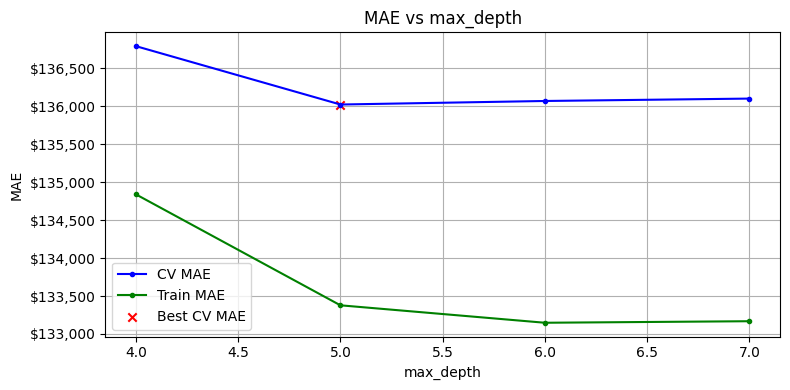

Execution Time: 00:00:28


{'max_iter': 100,
 'max_depth': 5,
 'max_features': 0.5,
 'max_leaf_nodes': 20,
 'min_samples_leaf': 1,
 'random_state': 42,
 'MAE_found': np.float64(136022.34601129757)}

In [32]:
# Add as many cells as you need
#tune Gradient Boosting model with sweep_parameters

#max_depth
sweep_parameter(model=gradient_boosting_model,
                Parameters=Params_GB,
                param='max_depth',
                parameter_list= range(4,8,1),
                n_repeats=5)


Sweeping max_iter: 100%|██████████| 10/10 [00:39<00:00,  3.98s/it]


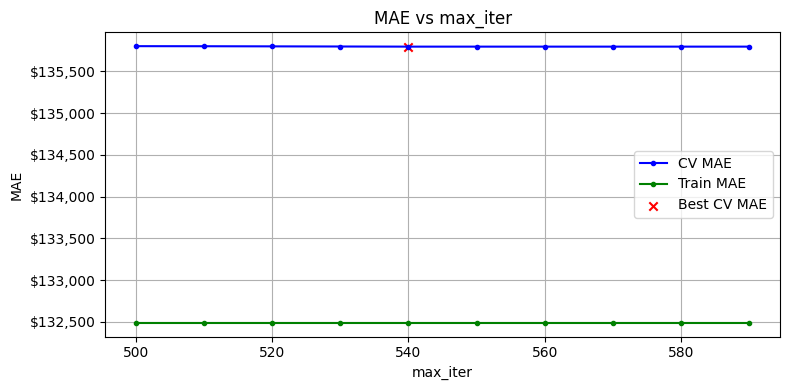

Execution Time: 00:00:39


{'max_iter': 540,
 'max_depth': 3,
 'max_features': 0.5,
 'max_leaf_nodes': 20,
 'min_samples_leaf': 1,
 'random_state': 42,
 'MAE_found': np.float64(135795.3064027965)}

In [33]:
sweep_parameter(model=gradient_boosting_model,
                Parameters=Params_GB,
                param='max_iter',
                parameter_list= range(500, 600, 10),
                n_repeats=5)

Sweeping max_leaf_nodes: 100%|██████████| 8/8 [00:10<00:00,  1.30s/it]


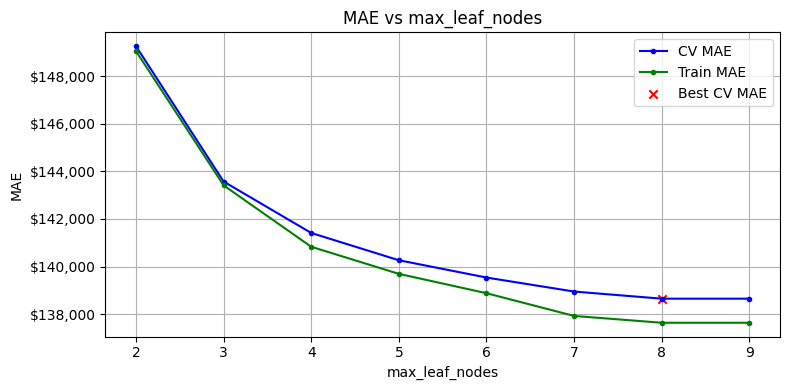

Execution Time: 00:00:10


{'max_iter': 100,
 'max_depth': 3,
 'max_features': 0.5,
 'max_leaf_nodes': 8,
 'min_samples_leaf': 1,
 'random_state': 42,
 'MAE_found': np.float64(138645.94425493543)}

In [34]:
sweep_parameter(model=gradient_boosting_model,
                Parameters=Params_GB,
                param='max_leaf_nodes',
                parameter_list= range(2,10,1),
                n_repeats=5)

Sweeping min_samples_leaf: 100%|██████████| 8/8 [00:11<00:00,  1.42s/it]


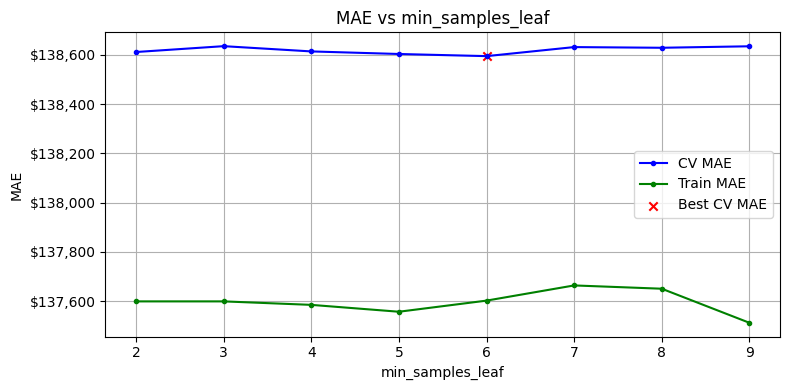

Execution Time: 00:00:11


{'max_iter': 100,
 'max_depth': 3,
 'max_features': 0.5,
 'max_leaf_nodes': 20,
 'min_samples_leaf': 6,
 'random_state': 42,
 'MAE_found': np.float64(138594.68357966735)}

In [35]:
sweep_parameter(model=gradient_boosting_model,
                Parameters=Params_GB,
                param='min_samples_leaf',
                parameter_list= range(2,10,1),
                n_repeats=5)

In [36]:
Tuned_Parameters_GB = {            
    'max_iter'                : 540,
    'max_depth'               : 5,               
    'max_features'            : 0.5, 
    'max_leaf_nodes'          : 8,          
    'min_samples_leaf'        : 6,              
    'random_state'            : random_state    
}

In [37]:
Tuned_GB_Model_sweep = run_model(model=HistGradientBoostingRegressor(**Tuned_Parameters_GB), X_train=X_train_selected, y_train=y_train_clean, n_repeats=5, n_jobs=-1)

print(f'Mean MAE: {(Tuned_GB_Model_sweep[0]):.4f}')
print(f'Standard Deviation: {(Tuned_GB_Model_sweep[1]):.4f}')

Mean MAE: 135891.9268
Standard Deviation: 1076.4476


In [38]:
from scipy.stats import randint as randint, uniform as uniform

In [39]:
#RandomGridSearch for GBHist
n_iterations = 60            # How many samples to take from the distributions shown here (rest are defaults):  

param_distributions = {
    'max_iter'                : randint(200,700),
    'max_depth'               : randint(2,7),               
    'max_features'            : uniform(0.01,0.99), 
    'max_leaf_nodes'          : randint(5,10),          
    'min_samples_leaf'        : randint(4,8),              
}

# Initialize the GradientBoostingRegressor
gbr = HistGradientBoostingRegressor(random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator           = gbr,
    param_distributions = param_distributions,
    n_iter              = n_iterations,                                                     
    cv                  = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42),        
    random_state        = 42,
    n_jobs              = -1,        
    verbose             = 1
)

# Fit the model
random_search.fit(X_train_selected, y_train_clean)

# Convert the CV results to a DataFrame
results_df = pd.DataFrame(random_search.cv_results_)

# Sort by mean test score (higher is better for negative MSE) and select the top 10
top10 = results_df.sort_values(by="mean_test_score", ascending=False).head(10)
results_df['mean_test_MAE'] = -results_df['mean_test_score']

# Print out the 10 best models with their parameters and scores
print("Top 10 models:")
print(top10[["params", "mean_test_score", "std_test_score"]])

# Output the best parameters and scores
print("Best parameters:",             random_search.best_params_)
print("Best cross-validation score:", random_search.best_score_)
print("Test set score:",              random_search.score(X_test_selected, y_test))

Fitting 10 folds for each of 60 candidates, totalling 600 fits
Top 10 models:
                                               params  mean_test_score  \
42  {'max_depth': 4, 'max_features': 0.37595791150...         0.443177   
10  {'max_depth': 3, 'max_features': 0.68739069624...         0.442780   
46  {'max_depth': 4, 'max_features': 0.81140603567...         0.442669   
57  {'max_depth': 5, 'max_features': 0.71505742913...         0.441937   
56  {'max_depth': 3, 'max_features': 0.49075761605...         0.441807   
41  {'max_depth': 3, 'max_features': 0.53562523748...         0.441586   
44  {'max_depth': 5, 'max_features': 0.51311678897...         0.440839   
51  {'max_depth': 5, 'max_features': 0.56271051907...         0.440701   
1   {'max_depth': 3, 'max_features': 0.16443457513...         0.440584   
4   {'max_depth': 5, 'max_features': 0.19157046475...         0.440460   

    std_test_score  
42        0.006180  
10        0.005401  
46        0.005947  
57        0.006564  
56

In [40]:
Tuned_Parameters_randsearch_GB = {            
    'max_iter'                : 600,
    'max_depth'               : 4,               
    'max_features'            : 0.3759, 
    'max_leaf_nodes'          : 9,          
    'min_samples_leaf'        : 7,              
    'random_state'            : random_state    
}

In [41]:
Tuned_GB_Model_randsearch = run_model(model=HistGradientBoostingRegressor(**Tuned_Parameters_randsearch_GB), X_train=X_train_selected, y_train=y_train_clean, n_repeats=5, n_jobs=-1)

print(f'Mean MAE: {(Tuned_GB_Model_randsearch[0]):.4f}')
print(f'Standard Deviation: {(Tuned_GB_Model_randsearch[1]):.4f}')

Mean MAE: 135742.3666
Standard Deviation: 1041.6192


Grid search ran for hours without completing, I am moving on to optuna.

In [42]:
import optuna

In [43]:
#optuna for GB
def objective(trial):
    max_feat = trial.suggest_float("max_features", 1e-3, 0.5, log=True)
    max_leaf = trial.suggest_int("max_leaf_nodes", 2, 256)
    max_d = trial.suggest_int("max_depth", 2, 10)
    min_leaf = trial.suggest_int("min_samples_leaf", 1,200)
   

    params_gb_optuna = {
    "max_features": max_feat,
    "max_leaf_nodes": max_leaf,
    "max_depth": max_d,
    "min_samples_leaf": min_leaf,

}

# 3) evaluate with cross_val_score (StratifiedKFold, scoring='f1')
    scores = cross_val_score(gradient_boosting_model.set_params(**params_gb_optuna),
                         X_train_selected, y_train_clean,
                         cv=cv,
                         scoring='neg_mean_absolute_error',    # or use make_scorer(f1_score)
                         n_jobs=-1)

    mean_f1 = float(np.mean(scores))

# 4) optional: report for pruning and prune if suggested
    trial.report(mean_f1, step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()

# 5) return the metric to be maximized
    return mean_f1

In [44]:
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0, interval_steps=1)
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=random_seed), pruner=pruner)

study.optimize(objective, n_trials=100, n_jobs=1, show_progress_bar=True)


[I 2026-04-10 07:46:36,017] A new study created in memory with name: no-name-22c3dc2c-b3cc-41b5-a14e-9b83731cab3a


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-10 07:46:38,476] Trial 0 finished with value: -136024.47488640196 and parameters: {'max_features': 0.010253509690168494, 'max_leaf_nodes': 244, 'max_depth': 8, 'min_samples_leaf': 120}. Best is trial 0 with value: -136024.47488640196.
[I 2026-04-10 07:46:39,461] Trial 1 finished with value: -146229.2669316966 and parameters: {'max_features': 0.0026368755339723046, 'max_leaf_nodes': 41, 'max_depth': 2, 'min_samples_leaf': 174}. Best is trial 0 with value: -136024.47488640196.
[I 2026-04-10 07:46:40,434] Trial 2 finished with value: -146239.07857726113 and parameters: {'max_features': 0.041917115166952006, 'max_leaf_nodes': 182, 'max_depth': 2, 'min_samples_leaf': 194}. Best is trial 0 with value: -136024.47488640196.
[I 2026-04-10 07:46:41,617] Trial 3 finished with value: -139498.1383943632 and parameters: {'max_features': 0.1764971584817571, 'max_leaf_nodes': 56, 'max_depth': 3, 'min_samples_leaf': 37}. Best is trial 0 with value: -136024.47488640196.
[I 2026-04-10 07:46:43

In [45]:
study.best_value

-134055.3123165372

In [46]:
study.best_params

{'max_features': 0.41169852417839725,
 'max_leaf_nodes': 132,
 'max_depth': 8,
 'min_samples_leaf': 44}

In [47]:
Tuned_Parameters_optuna_GB = {            
    'max_iter'                : 600,
    'max_depth'               : 8,               
    'max_features'            : 0.41169, 
    'max_leaf_nodes'          : 132,          
    'min_samples_leaf'        : 44,              
    'random_state'            : random_state    
}

In [48]:
Tuned_GB_Model_optuna = run_model(model=HistGradientBoostingRegressor(**Tuned_Parameters_optuna_GB), X_train=X_train_selected, y_train=y_train_clean, n_repeats=5, n_jobs=-1)

print(f'Mean MAE: {(Tuned_GB_Model_optuna[0]):.4f}')
print(f'Standard Deviation: {(Tuned_GB_Model_optuna[1]):.4f}')

Mean MAE: 134037.8804
Standard Deviation: 1131.0084


Linear regression models do not have hyperparameters that you can tune, per se.

In [49]:
Default_Parameters_RF = {            
    'n_estimators': 50,
'max_depth': 3,
'max_features': None,
'min_samples_split': 2,
'min_samples_leaf': 1,
}

In [50]:
Params_RF = Default_Parameters_RF.copy()

Sweeping n_estimators: 100%|██████████| 9/9 [18:21<00:00, 122.44s/it]


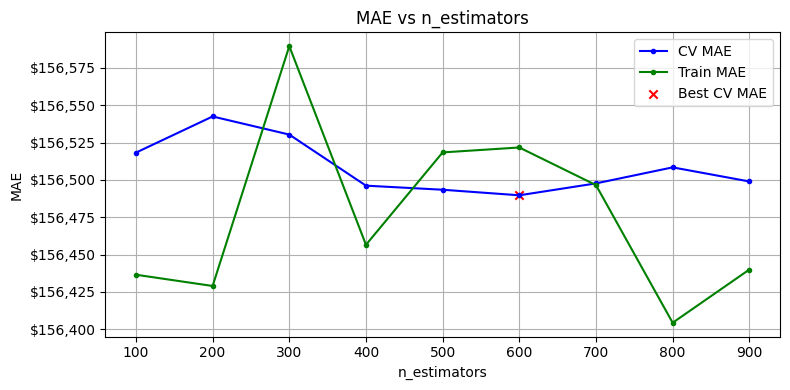

Execution Time: 00:18:22


{'n_estimators': 600,
 'max_depth': 3,
 'max_features': None,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'MAE_found': np.float64(156489.71636029292)}

In [51]:
sweep_parameter(model=RandomForestRegressor,
                Parameters=Params_RF,
                param='n_estimators',
                parameter_list= range(100,1000,100),
                n_repeats=5)


Sweeping max_depth: 100%|██████████| 3/3 [02:38<00:00, 52.70s/it]


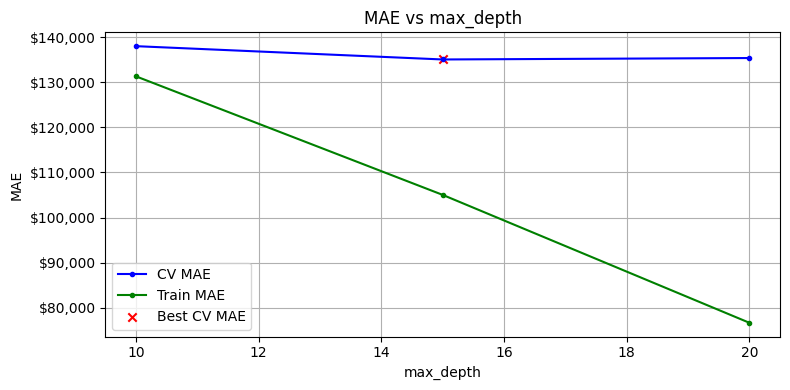

Execution Time: 00:02:38


{'n_estimators': 50,
 'max_depth': 15,
 'max_features': None,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'MAE_found': np.float64(135040.95409200471)}

In [52]:
sweep_parameter(model=RandomForestRegressor,
                Parameters=Params_RF,
                param='max_depth',
                parameter_list= range(10,21,5),
                n_repeats=5)

Sweeping min_samples_split: 100%|██████████| 6/6 [01:14<00:00, 12.45s/it]


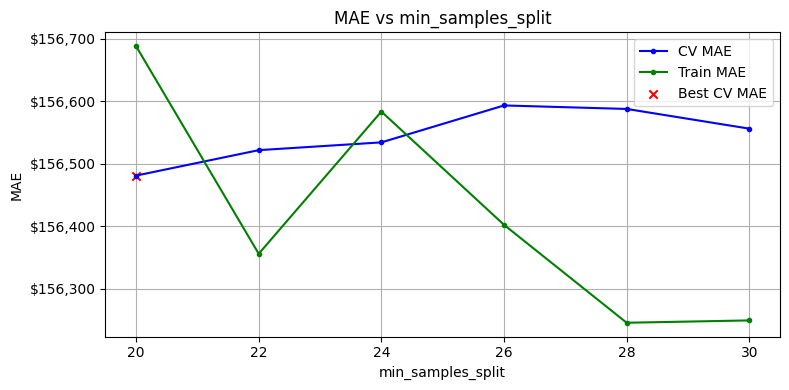

Execution Time: 00:01:14


{'n_estimators': 50,
 'max_depth': 3,
 'max_features': None,
 'min_samples_split': 20,
 'min_samples_leaf': 1,
 'MAE_found': np.float64(156480.93868331608)}

In [53]:
#i am having a difficult time nailing this one down. It keeps saying that it is at the extreme high or low
sweep_parameter(model=RandomForestRegressor,
                Parameters=Params_RF,
                param='min_samples_split',
                parameter_list= range(20,31,2),
                n_repeats=5)

Sweeping min_samples_leaf: 100%|██████████| 6/6 [01:14<00:00, 12.49s/it]


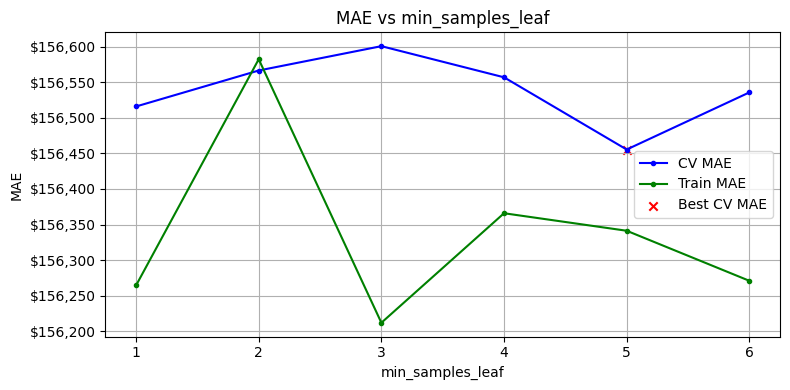

Execution Time: 00:01:15


{'n_estimators': 50,
 'max_depth': 3,
 'max_features': None,
 'min_samples_split': 2,
 'min_samples_leaf': 5,
 'MAE_found': np.float64(156455.34464994568)}

In [54]:
sweep_parameter(model=RandomForestRegressor,
                Parameters=Params_RF,
                param='min_samples_leaf',
                parameter_list= range(1,7,1),
                n_repeats=5)

In [61]:
Tuned_Parameters_RF_sweep = {            
    'n_estimators': 600,
'max_depth': 15,
'max_features': None,
'min_samples_split': 20,
'min_samples_leaf': 5,
}

In [62]:
Tuned_RF_Model_sweep = run_model(model=RandomForestRegressor(**Tuned_Parameters_RF_sweep), X_train=X_train_selected, y_train=y_train_clean, n_repeats=5, n_jobs=-1)

print(f'Mean MAE: {(Tuned_RF_Model_sweep[0]):.4f}')
print(f'Standard Deviation: {(Tuned_RF_Model_sweep[1]):.4f}')

Mean MAE: 134776.5750
Standard Deviation: 972.6293


In [55]:
#randomgridsearch for Random Forest
n_iterations = 60            # How many samples to take from the distributions shown here (rest are defaults):  

param_distributions = {
'n_estimators': randint(300, 500),
'max_depth': randint(10, 20),
'max_features': uniform(0.1, 0.5),
'min_samples_split': randint(2, 30),
'min_samples_leaf': randint(3,7),
}

# Initialize the GradientBoostingRegressor
gbr = RandomForestRegressor(random_state=42)

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator           = gbr,
    param_distributions = param_distributions,
    n_iter              = n_iterations,                                                     
    cv                  = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42),        
    random_state        = 42,
    n_jobs              = -1,        
    verbose             = 1
)

# Fit the model
random_search.fit(X_train_selected, y_train_clean)

# Convert the CV results to a DataFrame
results_df = pd.DataFrame(random_search.cv_results_)

# Sort by mean test score (higher is better for negative MSE) and select the top 10
top10 = results_df.sort_values(by="mean_test_score", ascending=False).head(10)
results_df['mean_test_MAE'] = -results_df['mean_test_score']

# Print out the 10 best models with their parameters and scores
print("Top 10 models:")
print(top10[["params", "mean_test_score", "std_test_score"]])

# Output the best parameters and scores
print("Best parameters:",             random_search.best_params_)
print("Best cross-validation score:", random_search.best_score_)
print("Test set score:",              random_search.score(X_test_selected, y_test))

Fitting 10 folds for each of 60 candidates, totalling 600 fits
Top 10 models:
                                               params  mean_test_score  \
36  {'max_depth': 17, 'max_features': 0.4515094794...         0.446120   
49  {'max_depth': 16, 'max_features': 0.5683649943...         0.446055   
51  {'max_depth': 16, 'max_features': 0.4299920230...         0.445849   
0   {'max_depth': 16, 'max_features': 0.4982714934...         0.445697   
16  {'max_depth': 16, 'max_features': 0.3604171300...         0.445671   
22  {'max_depth': 16, 'max_features': 0.5250192888...         0.445577   
47  {'max_depth': 19, 'max_features': 0.3560465291...         0.445433   
19  {'max_depth': 16, 'max_features': 0.3117007403...         0.445406   
34  {'max_depth': 15, 'max_features': 0.3553736512...         0.445391   
11  {'max_depth': 16, 'max_features': 0.4049983288...         0.445360   

    std_test_score  
36        0.006529  
49        0.006584  
51        0.006492  
0         0.006606  
16

In [63]:
Tuned_Parameters_RF_randsearch = {            
    'n_estimators': 485,
'max_depth': 17,
'max_features': 0.4515094,
'min_samples_split': 18,
'min_samples_leaf': 3,
}

In [64]:
Tuned_RF_Model_randsearch = run_model(model=RandomForestRegressor(**Tuned_Parameters_RF_randsearch), X_train=X_train_selected, y_train=y_train_clean, n_repeats=5, n_jobs=-1)

print(f'Mean MAE: {(Tuned_RF_Model_randsearch[0]):.4f}')
print(f'Standard Deviation: {(Tuned_RF_Model_randsearch[1]):.4f}')

Mean MAE: 134467.1639
Standard Deviation: 1020.1170


In [56]:
#optuna for RF
def objectiverf(trial):
    n_est = trial.suggest_int("n_estimators", 300, 500)
    max_feat = trial.suggest_float("max_features", 1e-3, 0.5, log=True)
    max_d = trial.suggest_int("max_depth", 10,20)
    min_leaf = trial.suggest_int("min_samples_leaf", 3,7)
    min_split = trial.suggest_int("min_samples_split", 2,30)

    params_rf_optuna = {

    "max_features": max_feat,
    "n_estimators": n_est,
    "max_depth": max_d,
    "min_samples_leaf": min_leaf,
    "min_samples_split": min_split

}

# 3) evaluate with cross_val_score (StratifiedKFold, scoring='meanabserror')
    scores = cross_val_score(random_forest_model.set_params(**params_rf_optuna),
                         X_train_selected, y_train_clean,
                         cv=cv,
                         scoring='neg_mean_absolute_error',    
                         n_jobs=-1)

    mean_abserror = float(np.mean(scores))

# 4) optional: report for pruning and prune if suggested
    trial.report(mean_abserror, step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()

# 5) return the metric to be maximized
    return mean_abserror

In [57]:
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0, interval_steps=1)
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=random_seed), pruner=pruner)

study.optimize(objectiverf, n_trials=100, n_jobs=1, show_progress_bar=True)


[I 2026-04-10 08:39:21,565] A new study created in memory with name: no-name-a2b12429-a1af-4b9b-a11a-922201dec4d8


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-10 08:40:56,139] Trial 0 finished with value: -134461.25969258577 and parameters: {'n_estimators': 375, 'max_features': 0.36808608148776095, 'max_depth': 18, 'min_samples_leaf': 5, 'min_samples_split': 6}. Best is trial 0 with value: -134461.25969258577.
[I 2026-04-10 08:41:18,110] Trial 1 finished with value: -137040.10167084736 and parameters: {'n_estimators': 331, 'max_features': 0.001434715951720141, 'max_depth': 19, 'min_samples_leaf': 6, 'min_samples_split': 22}. Best is trial 0 with value: -134461.25969258577.
[I 2026-04-10 08:42:52,793] Trial 2 finished with value: -134375.16529165008 and parameters: {'n_estimators': 304, 'max_features': 0.41472250004816347, 'max_depth': 19, 'min_samples_leaf': 4, 'min_samples_split': 7}. Best is trial 2 with value: -134375.16529165008.
[I 2026-04-10 08:43:13,985] Trial 3 finished with value: -137519.73308151565 and parameters: {'n_estimators': 336, 'max_features': 0.006624310605949983, 'max_depth': 15, 'min_samples_leaf': 5, 'min_sa

In [59]:
study.best_value

-134284.4388569708

In [60]:
study.best_params

{'n_estimators': 404,
 'max_features': 0.49869460880784555,
 'max_depth': 18,
 'min_samples_leaf': 3,
 'min_samples_split': 4}

In [65]:
Tuned_Parameters_RF_optuna = {            
    'n_estimators': 404,
'max_depth': 18,
'max_features': 0.498694,
'min_samples_split': 4,
'min_samples_leaf': 3,
}

In [66]:
Tuned_RF_Model_optuna = run_model(model=RandomForestRegressor(**Tuned_Parameters_RF_optuna), X_train=X_train_selected, y_train=y_train_clean, n_repeats=5, n_jobs=-1)

print(f'Mean MAE: {(Tuned_RF_Model_optuna[0]):.4f}')
print(f'Standard Deviation: {(Tuned_RF_Model_optuna[1]):.4f}')

Mean MAE: 134347.6534
Standard Deviation: 1049.9894


### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


My strategy was to look at the hyperparameters in each of the models and tune based on what we attempted in the homework. I set the default parameters to what was suggested in the homework. I sarted with the sweep_param approach for each model, then moved on to randomsearch and optuna. I used the more defined ranges from the sweep_param models to help inform which ranges were used in later anaysis. For the linear model, there was not much to tune in terms of hyperparameters. I ended up excluding that from the analysis due to tuning not impacting the outcome of the model's fitting. I also excluded the grid search, as it was taxing on my computer. I beleive that grid search could possibly output tuned parameters if you have the time and compute to run the process. 

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants.

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set.




In [58]:
# Add as many cells as you need


### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

> Your text here